In [ ]:
! pip install spectral_cube
! pip install pvextractor
! pip install google.colab

DEPRECATION: Loading egg at /home/tubal/miniconda3/envs/sf3d/lib/python3.11/site-packages/sf3dmodels-0.0.dev1485-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/tubal/miniconda3/envs/sf3d/lib/python3.11/site-packages/sf3dmodels-0.0.dev1485-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /home/tubal/miniconda3/envs/sf3d/lib/python3.11/site-packages/sf3dmodels-0.0.dev1485-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [2]:
from astropy import units as u
from spectral_cube import SpectralCube
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import matplotlib.colors as colors

from pvextractor import extract_pv_slice, Path


ModuleNotFoundError: No module named 'google.colab'

In [ ]:
# read the data
data_file = '/content/drive/MyDrive/CH3CN_19-18_K4_ALMA.fits'
cube = SpectralCube.read(data_file)


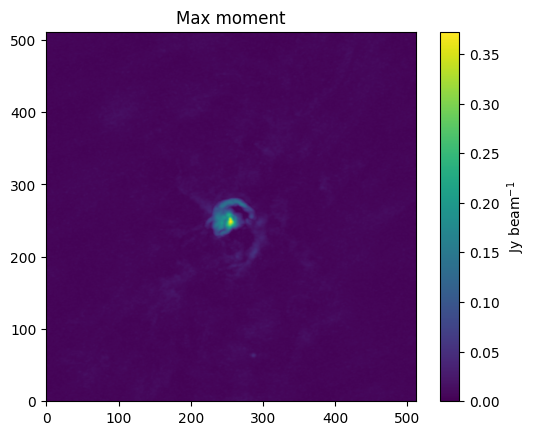

In [ ]:
# max cube (moment8)   # maximum value of the spectrum
max_map = cube.max(axis=0).value # axis=0 means in the axis of frequency
img = plt.imshow(max_map, cmap='viridis', origin='lower') #norm = colors.LogNorm())# norm = colors.AsinhNorm())
cbar = plt.colorbar(img, label=r'$\mathrm{Jy \ beam^{-1}}$')
plt.title('Max moment')
plt.show()

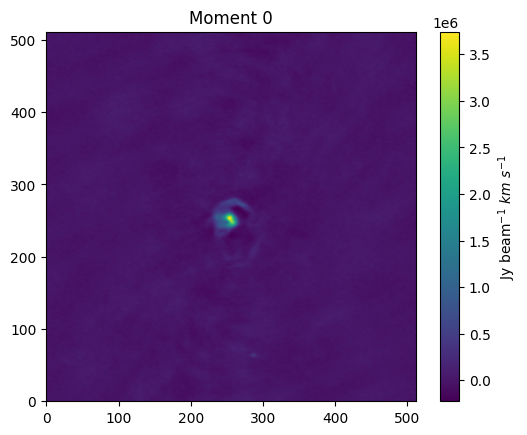

In [ ]:
# moment0 = \int I_nu d_v  #integrated value of the spectrum
moment_0 = cube.moment(order=0).value # axis=0 means in the axis of frequency
#print(moment_0)
img = plt.imshow(moment_0, cmap='viridis',origin='lower' ) #norm = colors.LogNorm())# norm = colors.AsinhNorm())
cbar = plt.colorbar(img, label=r'$\mathrm{Jy \ beam^{-1}} \ km \ s^{-1}$')
plt.title('Moment 0')
plt.show()

/usr/local/lib/python3.12/dist-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


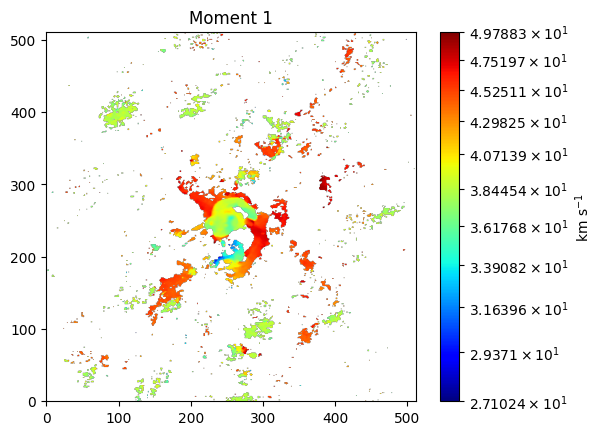

In [ ]:
# moment_1 = \int (v I_nu d_v)/M0    # intensity weighted coordinate #v = velocidad

# we need to add a mask
RMS = 1.941591911478e-3 *u.Jy/u.beam
mask = cube > 5*RMS
CH3CN_freq = 3.493463400000E+11 *u.Hz
cube_mask = cube.with_mask(mask)

cube3 = cube_mask.with_spectral_unit(u.km/u.s,
                                    velocity_convention='optical',
                                    rest_value=CH3CN_freq)
#optional:
#subcube = cube3.spectral_slab(-60*u.km/u.s,-20*u.km/u.s)
#moment_1 = subcube.moment(order=1).value
moment_1 = cube3.moment(order=1).value # axis=0 means in the axis of frequency
img = plt.imshow(moment_1, cmap='jet', norm = colors.AsinhNorm(linear_width=1), origin='lower')
cbar = plt.colorbar(img, label=r'$\mathrm{km \ s^{-1}}$')
plt.title('Moment 1')
plt.show()

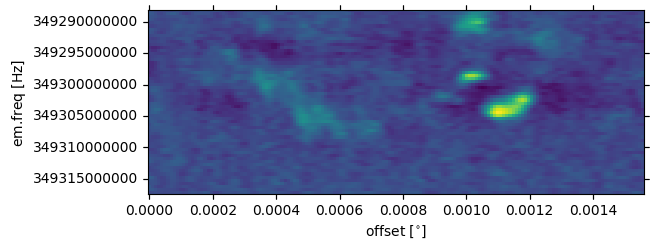

In [ ]:
from numpy import extract
from astropy.wcs import WCS
# PV diagram
path = Path([(240,150),(300,300)])
pv = extract_pv_slice(cube, path)

ww = WCS(pv.header)
ax = plt.subplot(111, projection=ww)
ax.imshow(pv.data, cmap='viridis', origin='lower')

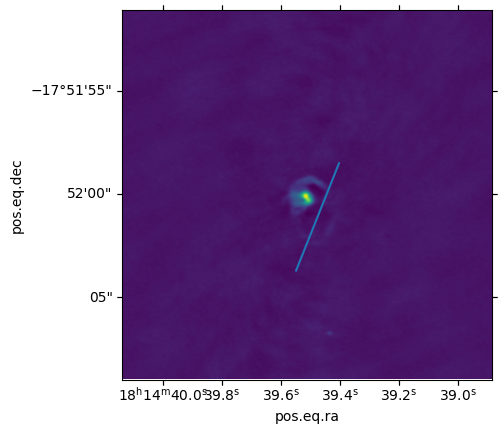

In [ ]:
ax = plt.subplot(111, projection = cube.wcs.celestial)
ax.imshow(cube.moment0(axis=0).value, origin='lower')
path.show_on_axis(ax, spacing=1)